<a href="https://colab.research.google.com/github/Abdisa-cyber/Data-Preprocessing-for-ML-using-Titanic-Dataset/blob/main/Employee_Salary_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving employee_salary_dataset.csv to employee_salary_dataset.csv


In [4]:
import pandas as pd

data = {
    "education": [
        "Bachelor","Bachelor","Master","Bachelor","Master","PhD","Bachelor",
        "Master","Master","Bachelor","Master","PhD","Bachelor","Master","PhD"
    ],
    "job_role": [
        "Engineer","Engineer","Engineer","Analyst","Analyst","Manager","Clerk",
        "Engineer","Manager","Engineer","Analyst","Engineer","Clerk","Engineer","Manager"
    ],
    "experience_level": [
        "Junior","Mid","Senior","Junior","Mid","Senior","Junior",
        "Mid","Senior","Junior","Senior","Senior","Mid","Mid","Senior"
    ],
    "department": [
        "IT","IT","IT","Finance","Finance","HR","HR",
        "IT","Finance","IT","Finance","IT","HR","IT","Finance"
    ],
    "location": [
        "Urban","Urban","Urban","Urban","Rural","Urban","Rural",
        "Rural","Urban","Rural","Urban","Urban","Rural","Urban","Urban"
    ],
    "performance": [
        "Average","Good","Excellent","Average","Good","Excellent","Average",
        "Good","Excellent","Average","Good","Excellent","Average","Good","Excellent"
    ],
    "salary_level": [
        "Low","Medium","High","Low","Medium","High","Low",
        "Medium","High","Low","High","High","Low","Medium","High"
    ]
}

df = pd.DataFrame(data)
df.to_csv("employee_salary.csv", index=False)

print("employee_salary.csv created successfully!")
df.head()


employee_salary.csv created successfully!


,education,job_role,experience_level,department,location,performance,salary_level
0,Bachelor,Engineer,Junior,IT,Urban,Average,Low
1,Bachelor,Engineer,Mid,IT,Urban,Good,Medium
2,Master,Engineer,Senior,IT,Urban,Excellent,High
3,Bachelor,Analyst,Junior,Finance,Urban,Average,Low
4,Master,Analyst,Mid,Finance,Rural,Good,Medium


In [5]:
import pandas as pd

df = pd.read_csv("employee_salary.csv")
df


,education,job_role,experience_level,department,location,performance,salary_level
0,Bachelor,Engineer,Junior,IT,Urban,Average,Low
1,Bachelor,Engineer,Mid,IT,Urban,Good,Medium
2,Master,Engineer,Senior,IT,Urban,Excellent,High
3,Bachelor,Analyst,Junior,Finance,Urban,Average,Low
4,Master,Analyst,Mid,Finance,Rural,Good,Medium
5,PhD,Manager,Senior,HR,Urban,Excellent,High
6,Bachelor,Clerk,Junior,HR,Rural,Average,Low
7,Master,Engineer,Mid,IT,Rural,Good,Medium
8,Master,Manager,Senior,Finance,Urban,Excellent,High
9,Bachelor,Engineer,Junior,IT,Rural,Average,Low


In [6]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")


Shape: (15, 7)

Missing Values:
 education           0
job_role            0
experience_level    0
department          0
location            0
performance         0
salary_level        0
dtype: int64

Data Types:
 education           object
job_role            object
experience_level    object
department          object
location            object
performance         object
salary_level        object
dtype: object

Unique values per column:
education: ['Bachelor' 'Master' 'PhD']
job_role: ['Engineer' 'Analyst' 'Manager' 'Clerk']
experience_level: ['Junior' 'Mid' 'Senior']
department: ['IT' 'Finance' 'HR']
location: ['Urban' 'Rural']
performance: ['Average' 'Good' 'Excellent']
salary_level: ['Low' 'Medium' 'High']


In [7]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

df_encoded


,education,job_role,experience_level,department,location,performance,salary_level
0,0,2,0,2,1,0,1
1,0,2,1,2,1,2,2
2,1,2,2,2,1,1,0
3,0,0,0,0,1,0,1
4,1,0,1,0,0,2,2
5,2,3,2,1,1,1,0
6,0,1,0,1,0,0,1
7,1,2,1,2,0,2,2
8,1,3,2,0,1,1,0
9,0,2,0,2,0,0,1


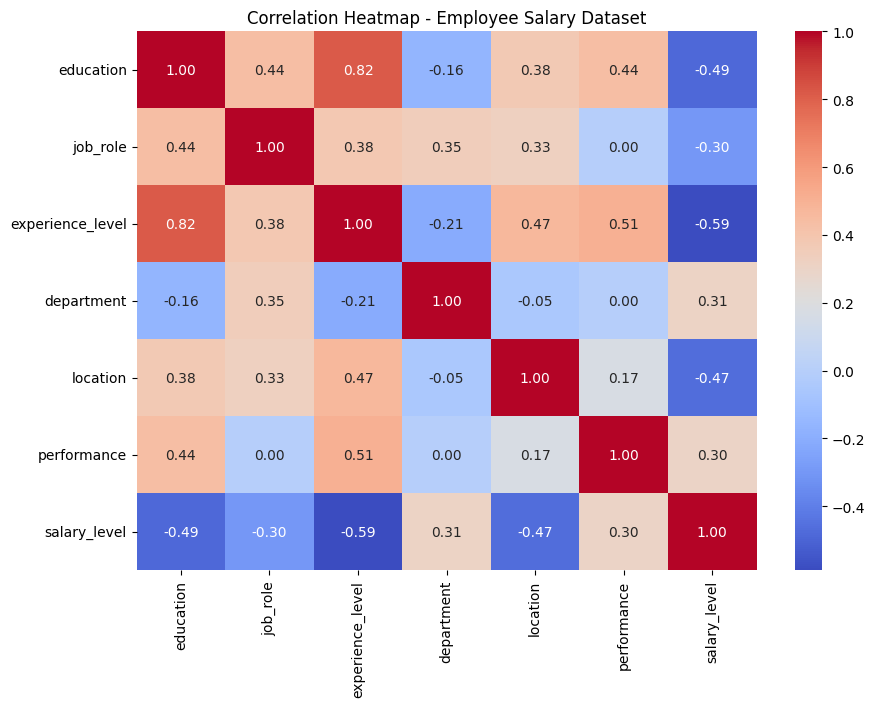

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Employee Salary Dataset")
plt.show()


In [9]:
X = df_encoded.drop("salary_level", axis=1)
y = df_encoded["salary_level"]


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

criteria = ["gini", "entropy", "log_loss"]
results = {}

for c in criteria:
    model = DecisionTreeClassifier(criterion=c, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[c] = acc

results


{'gini': 1.0, 'entropy': 1.0, 'log_loss': 1.0}